In [1]:
import torch 
import torch.nn as nn 
import numpy as np
from src.spatial_attn_lightning import BinauralAttentionModule #probably need to change this to the new name

import yaml 
from copy import deepcopy

%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display, Audio

torch.set_float32_matmul_precision('medium')
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

In [2]:
## Get backbone model 


config_path = "config/binaural_attn/word_task_v10_backbone_word_config.yaml"
# config_path = "config/binaural_attn/word_task_half_co_loc_v06.yaml"
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

ckpt_path = "attn_cue_models/word_task_v10_backbone_word_config/checkpoints/epoch=3-step=6227.ckpt"


backbone_no_gain = BinauralAttentionModule.load_from_checkpoint(checkpoint_path=ckpt_path, config=config).eval().cuda()


/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/pytorch_lightning/utilities/migration/utils.py:55: The loaded checkpoint was produced with Lightning v2.5.0.post0, which is newer than your current Lightning version: v2.1.1


Using explicit dim specification for demeaning in audio transforms
Batch in dataloader = True
Using BackBoneCNN
num_classes={'num_words': 800}
Model performing word task
Conv block order: LN -> Conv -> ReLU
Using dataset BinauralWordRecDataset
OptimizedModule(
  (_orig_mod): BackBoneCNN(
    (model_dict): ModuleDict(
      (norm_coch_rep): LayerNorm((2, 40, 20000), eps=1e-05, elementwise_affine=True)
      (conv_block_0): Sequential(
        (0): LayerNorm((2, 40, 20000), eps=1e-05, elementwise_affine=True)
        (1): Conv2d(2, 32, kernel_size=(2, 34), stride=(1, 1), bias=False)
        (2): ReLU()
      )
      (hann_pool_0): HannPooling2d()
      (conv_block_1): Sequential(
        (0): LayerNorm((32, 20, 4992), eps=1e-05, elementwise_affine=True)
        (1): Conv2d(32, 64, kernel_size=(2, 14), stride=(1, 1), bias=False)
        (2): ReLU()
      )
      (hann_pool_1): HannPooling2d()
      (conv_block_2): Sequential(
        (0): LayerNorm((64, 10, 1245), eps=1e-05, elementwise_a

/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/torchaudio/functional/functional.py:1371: UserWarning: "kaiser_window" resampling method name is being deprecated and replaced by "sinc_interp_kaiser" in the next release. The default behavior remains unchanged.
  warnings.warn(


In [3]:
ecdf_config = deepcopy(config)
ecdf_config['model']['backbone_with_ecdf_gains'] = True

backbone_ecdf_gains = BinauralAttentionModule.load_from_checkpoint(checkpoint_path=ckpt_path, config=ecdf_config, strict=False).eval().cuda()



Using explicit dim specification for demeaning in audio transforms
Batch in dataloader = False
Using BackBoneWithECDFGains
num_classes={'num_words': 800}
Model performing word task
Conv block order: LN -> Conv -> ReLU
Using ECDFGains
Using dataset BinauralAttentionDataset
OptimizedModule(
  (_orig_mod): BackBoneWithECDFGains(
    (model_dict): ModuleDict(
      (norm_coch_rep): LayerNorm((2, 40, 20000), eps=1e-05, elementwise_affine=True)
      (attn0): ECDFGains()
      (conv_block_0): Sequential(
        (0): LayerNorm((2, 40, 20000), eps=1e-05, elementwise_affine=True)
        (1): Conv2d(2, 32, kernel_size=(2, 34), stride=(1, 1), bias=False)
        (2): ReLU()
      )
      (hann_pool_0): HannPooling2d()
      (attn1): ECDFGains()
      (conv_block_1): Sequential(
        (0): LayerNorm((32, 20, 4992), eps=1e-05, elementwise_affine=True)
        (1): Conv2d(32, 64, kernel_size=(2, 14), stride=(1, 1), bias=False)
        (2): ReLU()
      )
      (hann_pool_1): HannPooling2d()
    

/om2/user/imgriff/conda_envs/pytorch_2/lib/python3.11/site-packages/pytorch_lightning/core/saving.py:173: Found keys that are in the model state dict but not in the checkpoint: ['model._orig_mod.model_dict.attn0.cdf_probs', 'model._orig_mod.model_dict.attn1.cdf_probs', 'model._orig_mod.model_dict.attn2.cdf_probs', 'model._orig_mod.model_dict.attn3.cdf_probs', 'model._orig_mod.model_dict.attn4.cdf_probs', 'model._orig_mod.model_dict.attn5.cdf_probs', 'model._orig_mod.model_dict.attn6.cdf_probs', 'model._orig_mod.model_dict.attnfc.cdf_probs']


In [4]:
ecdf_feature_config = deepcopy(config)
ecdf_feature_config['model']['backbone_with_ecdf_gains'] = True
ecdf_feature_config['model']['gain_type'] = 'ECDFFeatureGains'

backbone_ecdf_feature_gains = BinauralAttentionModule.load_from_checkpoint(checkpoint_path=ckpt_path, config=ecdf_feature_config, strict=False).eval().cuda()

Using explicit dim specification for demeaning in audio transforms
Batch in dataloader = False
Using BackBoneWithECDFGains
num_classes={'num_words': 800}
Model performing word task
Conv block order: LN -> Conv -> ReLU
Using ECDFFeatureGains
Using dataset BinauralAttentionDataset
OptimizedModule(
  (_orig_mod): BackBoneWithECDFGains(
    (model_dict): ModuleDict(
      (norm_coch_rep): LayerNorm((2, 40, 20000), eps=1e-05, elementwise_affine=True)
      (attn0): ECDFFeatureGains()
      (conv_block_0): Sequential(
        (0): LayerNorm((2, 40, 20000), eps=1e-05, elementwise_affine=True)
        (1): Conv2d(2, 32, kernel_size=(2, 34), stride=(1, 1), bias=False)
        (2): ReLU()
      )
      (hann_pool_0): HannPooling2d()
      (attn1): ECDFFeatureGains()
      (conv_block_1): Sequential(
        (0): LayerNorm((32, 20, 4992), eps=1e-05, elementwise_affine=True)
        (1): Conv2d(32, 64, kernel_size=(2, 14), stride=(1, 1), bias=False)
        (2): ReLU()
      )
      (hann_pool_1):

In [7]:
cochleagram = backbone_no_gain.coch_gram.cuda()

In [6]:
import src.audio_transforms as at

snr = 0
audio_transforms = at.AudioCompose([
            at.AudioToTensor(),
            at.CombineWithRandomDBSNR(low_snr=snr, high_snr=snr), 
            at.RMSNormalizeForegroundAndBackground(rms_level=0.02),  # 0.02 is the default for CV-based models 
            at.DuplicateChannel(),
            at.UnsqueezeAudio(dim=0),
            ])

In [19]:
## Get a training example and see if outputs are identical 

from corpus.swc_mono_test import SWCMonoTestSetH5Dataset

stim_path = "/om/user/imgriff/datasets/human_word_rec_SWC_2024/model_eval_stim.h5"
condition = 'natural_scene'

dataset = SWCMonoTestSetH5Dataset(h5_path=stim_path,
                                    eval_distractor_cond=condition,
                                    model_sr=44_100,
                                            label_type="CV")

cue, target, distractor, word_int, dist_word_int = dataset[1]
cue, _ = audio_transforms(cue, None)
mixture, _ = audio_transforms(target, distractor)
target, _ = audio_transforms(target, None)
distractor, _ = audio_transforms(distractor, None)
display(Audio(cue.squeeze().cpu().numpy(), rate=44_100))
display(Audio(target.squeeze().cpu().numpy(), rate=44_100))
display(Audio(distractor.squeeze().cpu().numpy(), rate=44_100))
display(Audio(mixture.squeeze().cpu().numpy(), rate=44_100))


In [20]:
class_map = dataset.get_class_map()
ix_to_word = {v:k for k,v in class_map.items()}

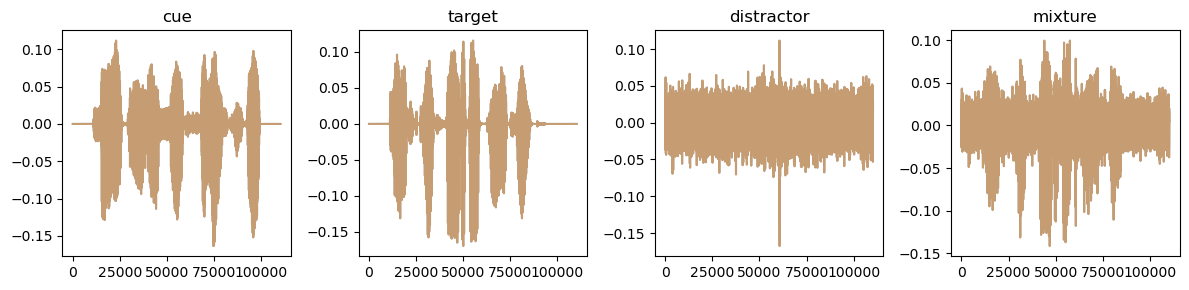

In [21]:
fig, axes = plt.subplots(1,4, figsize=(12,3))
axes[0].plot(cue.squeeze().numpy().T, alpha=0.5);
axes[0].set_title('cue')
axes[1].plot(target.squeeze().numpy().T, alpha=0.5);
axes[1].set_title('target')
axes[2].plot(distractor.squeeze().numpy().T, alpha=0.5);
axes[2].set_title('distractor')
axes[3].plot(mixture.squeeze().numpy().T, alpha=0.5);
axes[3].set_title('mixture')
plt.tight_layout()

In [22]:
## Check that models give same output for target alone but different outputs for mixture

cue_cg, target_cg = cochleagram(cue.cuda(), target.cuda())

mixture_cg, distractor_cg = cochleagram(mixture.cuda(), distractor.cuda())

In [23]:
with torch.no_grad():
    # target alone
    backbone_target_out = backbone_no_gain(None, target_cg, None).cpu().softmax(-1)
    w_gain_target_out = backbone_ecdf_gains(cue_cg, target_cg, None).cpu().softmax(-1)
    w_feature_gain_target_out = backbone_ecdf_feature_gains(cue_cg, target_cg, None).cpu().softmax(-1)

    # mixture
    backbone_mixture_out = backbone_no_gain(None, mixture_cg, None).cpu().softmax(-1)
    w_gain_mixture_out = backbone_ecdf_gains(cue_cg, mixture_cg, None).cpu().softmax(-1)
    w_feature_gain_mixture_out = backbone_ecdf_feature_gains(cue_cg, mixture_cg, None).cpu().softmax(-1)


In [45]:
## Get judgements 

no_gain_tgt_hit = word_int == backbone_target_out.argmax(-1)
w_gain_tgt_hit = word_int == w_gain_target_out.argmax(-1)
w_feature_gain_tgt_hit = word_int == w_feature_gain_target_out.argmax(-1)

no_gain_mixture_hit = word_int == backbone_mixture_out.argmax(-1)
w_gain_mixture_hit = word_int == w_gain_mixture_out.argmax(-1)
w_feature_gain_mixture_hit = word_int == w_feature_gain_mixture_out.argmax(-1)


print(f"no gain target hit: {no_gain_tgt_hit.sum()}/{len(no_gain_tgt_hit)}")
print(f"w gain target hit: {w_gain_tgt_hit.sum()}/{len(w_gain_tgt_hit)}")
print(f"w feature gain target hit: {w_feature_gain_tgt_hit.sum()}/{len(w_feature_gain_tgt_hit)}")
print(f"no gain mixture hit: {no_gain_mixture_hit.sum()}/{len(no_gain_mixture_hit)}")
print(f"w gain mixture hit: {w_gain_mixture_hit.sum()}/{len(w_gain_mixture_hit)}")
print(f"w feature gain mixture hit: {w_feature_gain_mixture_hit.sum()}/{len(w_feature_gain_mixture_hit)}")


no gain target hit: 1/1
w gain target hit: 1/1
w feature gain target hit: 1/1
no gain mixture hit: 1/1
w gain mixture hit: 0/1
w feature gain mixture hit: 0/1


False
False


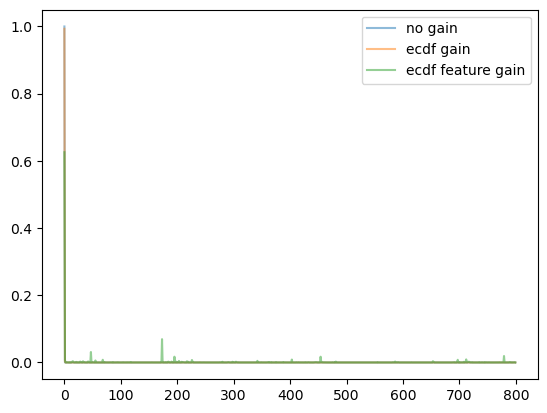

In [25]:
plt.plot(backbone_target_out.squeeze().numpy(), alpha=0.5, label='no gain')
plt.plot(w_gain_target_out.squeeze().numpy(), alpha=0.5, label='ecdf gain')
plt.plot(w_feature_gain_target_out.squeeze().numpy(), alpha=0.5, label='ecdf feature gain')
plt.legend()

print(torch.equal(backbone_target_out, w_gain_target_out))
print(torch.equal(backbone_target_out, w_feature_gain_target_out))

False
False


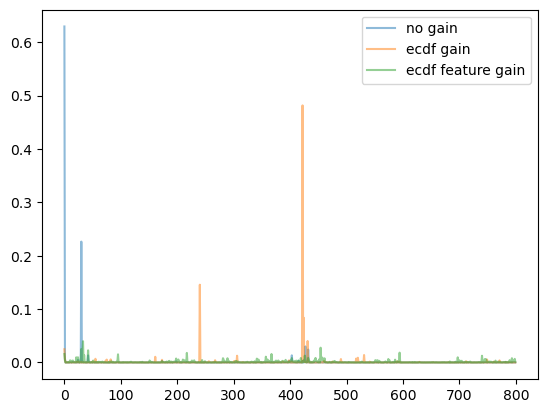

In [44]:
plt.plot(backbone_mixture_out.squeeze().numpy(), alpha=0.5, label='no gain')
plt.plot(w_gain_mixture_out.squeeze().numpy(), alpha=0.5, label='ecdf gain')
plt.plot(w_feature_gain_mixture_out.squeeze().numpy(), alpha=0.5, label='ecdf feature gain')
plt.legend()
print(torch.equal(backbone_mixture_out, w_gain_mixture_out))
print(torch.equal(backbone_mixture_out, w_feature_gain_mixture_out))

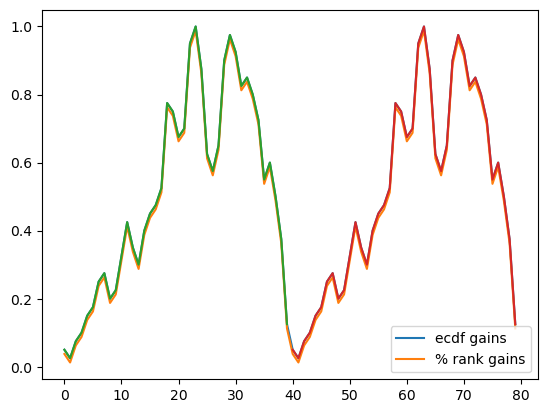

In [46]:
### Dev feature mean ECDFGains

feature_means = cue_cg.mean(dim=-1, keepdim=True)


cdf_ixs = torch.linspace(1./80, 1, 80, dtype=torch.float)
# flatten dims
feature_flat = feature_means.flatten(start_dim=1)
feature_dist = feature_flat.sort(dim=-1).values.contiguous()

gain_ixs = torch.searchsorted(feature_dist, feature_flat, right=True)-1

div_gains = gain_ixs.float().cpu() / feature_flat.shape[-1]  # this is the gain for each feature


cdf_feature_gains = cdf_ixs[gain_ixs.cpu()]
plt.plot(cdf_feature_gains.numpy().squeeze(), label='ecdf gains');
plt.plot(div_gains.numpy().squeeze(), label='% rank gains');
plt.legend()


# set shape back to match mixture dims 
cdf_feature_gains = cdf_feature_gains.view(cue_cg.shape[0], cue_cg.shape[1], cue_cg.shape[2], -1)
plt.plot(cdf_feature_gains[:,0,:].numpy().squeeze())
plt.plot(np.arange(40,80),cdf_feature_gains[:,1,:].numpy().squeeze())

In [56]:
from importlib import reload
import src.spatial_attn_architecture  as arch 
reload(arch)
ECDFFeatureGains = arch.ECDFFeatureGains
ECDFGains = arch.ECDFGains

gain_fn = ECDFFeatureGains(80).cuda()
ecdf_gain_fn = ECDFGains(cue_cg.shape[-1]).cuda()

gains = gain_fn(cue_cg)
ecdf_gains = ecdf_gain_fn(cue_cg).cpu()

In [54]:
ecdf_gains.shape

torch.Size([1, 2, 40, 1])

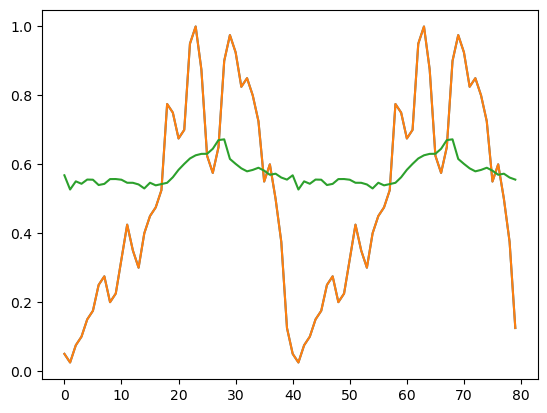

In [57]:
plt.plot(gains.squeeze().ravel().cpu().numpy(), label='torch module gains');
plt.plot(cdf_feature_gains.squeeze().numpy().ravel(), label='ecdf gains');
plt.plot(ecdf_gains.squeeze().numpy().ravel(), label='ecdf gains');


In [36]:
## Compare pre and post gain 

attn_mix_cg = gain_fn(cue_cg, mixture_cg)
attn_time_cg = ecdf_gain_fn(cue_cg, mixture_cg)

In [40]:
cue_cg.min()

tensor(0.0079, device='cuda:0')

Text(0.5, 1.0, 'time attn mixture')

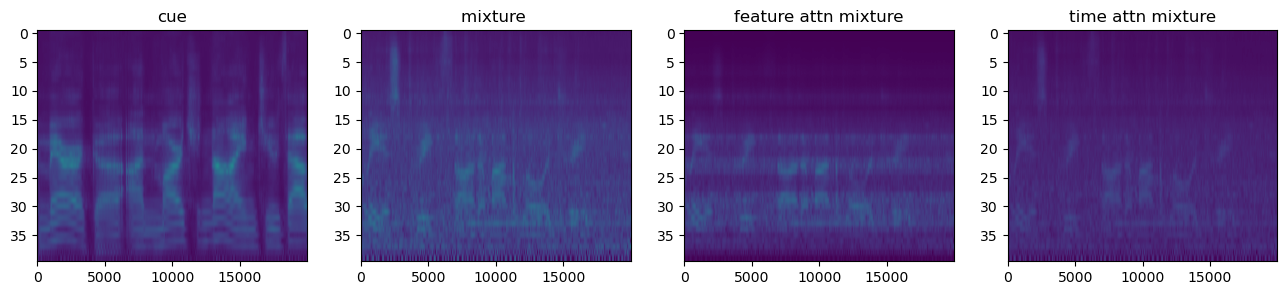

In [42]:
fig, axes = plt.subplots(1,4, figsize=(16,3))

vmin, vmax = 0, cue_cg.max().item()
axes[0].imshow(cue_cg[0,0].cpu().numpy(), aspect='auto', origin='upper', vmin=vmin, vmax=vmax);
axes[0].set_title('cue')
axes[1].imshow(mixture_cg[0,0].cpu().numpy(), aspect='auto', origin='upper', vmin=vmin, vmax=vmax);
axes[1].set_title('mixture ')
axes[2].imshow(attn_mix_cg[0,0].cpu().numpy(), aspect='auto', origin='upper', vmin=vmin, vmax=vmax);
axes[2].set_title('feature attn mixture')
axes[3].imshow(attn_time_cg[0,0].cpu().numpy(), aspect='auto', origin='upper', vmin=vmin, vmax=vmax);
axes[3].set_title('time attn mixture')